# Static image

This is an example of applying retinomorphic convolution to a static image. It also demonstrates how the different layers are built and shows some plots of cells and their receptive fields for each layer.

In [1]:
from typing import *

# --------------------------------------
from pathlib import Path

# --------------------------------------
import torch as pt

# --------------------------------------
import numpy as np

# --------------------------------------
import skimage

# --------------------------------------
import pyrception.visual.util.types as pct
import pyrception.util.functions as pf
from pyrception.visual.layers import ReceptorLayer
from pyrception.visual.layers import HorizontalLayer
from pyrception.visual.layers import BipolarLayer
from pyrception.visual.layers import AmacrineLayer
from pyrception.visual.layers import GanglionLayer
from pyrception.visual.util.types import ImagePlot
from pyrception.visual.util.types import ScatterPlot

Pyrception | 2024-06-27@00:07:04 | Logger configured.
Pyrception | 2024-06-27@00:07:04 | Default PyTorch tensor type: 'torch.float32'.
Pyrception | 2024-06-27@00:07:04 | Default PyTorch device: 'cpu'.


## Open an image

In [2]:
img_path = Path("./resources/cat.jpg")
if not img_path.exists():
    raise FileNotFoundError(f"Invalid path {img_path}")

img = pt.from_numpy(skimage.io.imread(img_path, as_gray=True).astype(np.float32))

## Setup

In [3]:
(h, w) = img.shape
size = (h, w)

plot_kw = {}

image_kw = {}

scatter_kw = {
    "axis": True,
    "spines": True,
}

Show the image that we are working with 

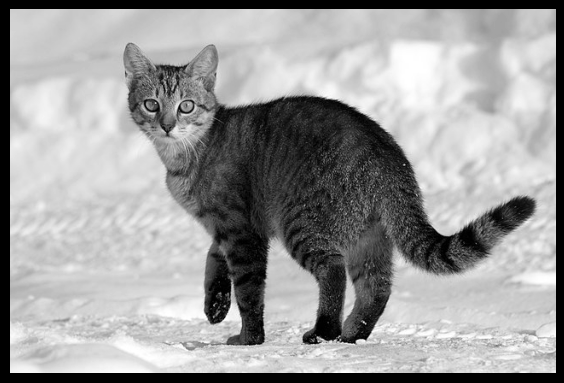

In [4]:
(fig, _, _) = pf.plot(img, **plot_kw)

Convenience functions for plotting parameters

In [5]:
def implot(x: np.ndarray, **kwargs):
    kw = image_kw.copy()
    kw.update(kwargs)
    return ImagePlot(x, **kwargs)

def scatplot(x: np.ndarray, **kwargs):
    kw = image_kw.copy()
    kw.update(kwargs)
    return ScatterPlot(x, **kwargs)

## Receptor layer

In [6]:
rl_params = {
    "size": size,
}

rl = ReceptorLayer(**rl_params)

Pyrception | 2024-06-27@00:07:05 | Receptor | Initialising...
Pyrception | 2024-06-27@00:07:05 | Receptor | Initialised.


## Horizontal layer

In [7]:
hl_params = {
    "size": size,
    "receptor": rl,
    "sectors": 64,
    "rf_params": {
        "kernel_params": {
            "filter": pct.KernelFilter.Gaussian,
            "min_size": 3,
            "scale": 1.0,
        }
    },
}

hl = HorizontalLayer(**hl_params)

Pyrception | 2024-06-27@00:07:05 | Horizontal | Initialising...
Pyrception | 2024-06-27@00:07:05 | Horizontal | Horizontal RFs | Creating receptive fields...


Neurons created: 100%|██████████| 2595/2595 [00:04<00:00, 613.68it/s]
/home/hobbes/code/gitlab/pyrception/remote/pyrception/visual/rf.py:908: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969073/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  .to_sparse_csr()


Pyrception | 2024-06-27@00:07:11 | Horizontal | Horizontal RFs | Receptive fields created for 2595 neurons.
Pyrception | 2024-06-27@00:07:11 | Horizontal | Initialised.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


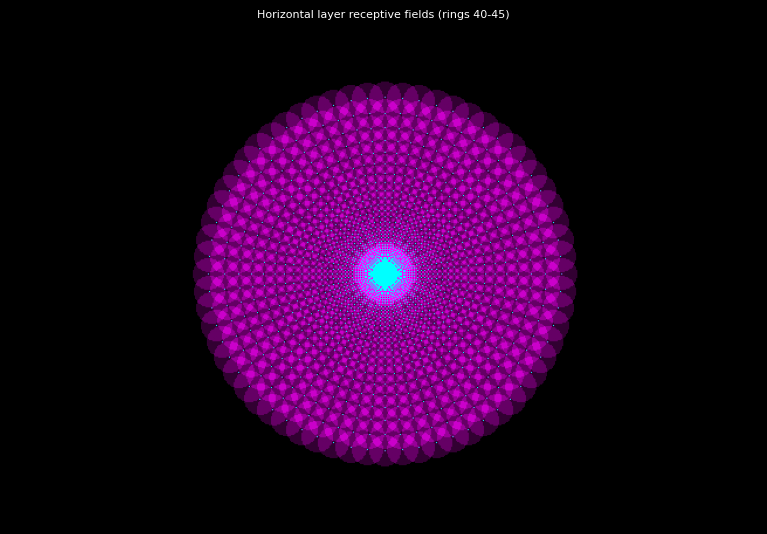

In [8]:
rbegin = 40
rend = 45

(fig, ax, _, _) = hl.plot_rfs(
    cells=hl.rfs.rings[:rend],
    title=f"Horizontal layer receptive fields (rings {rbegin}-{rend})",
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


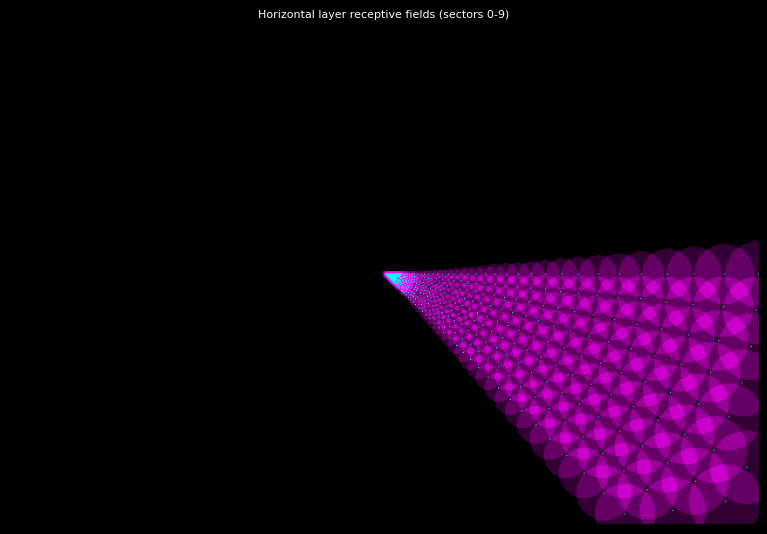

In [9]:
sbegin = 0
send = 9
(fig, ax, _, _) = hl.plot_rfs(
    cells=hl.rfs.sectors[sbegin:send],
    title=f"Horizontal layer receptive fields (sectors {sbegin}-{send})",
)

## Bipolar layer

In [10]:
bl_params = {
    "size": size,
    "receptor": rl,
    "horizontal": hl,
    "sectors": 128,
    "rf_params": {
        "kernel_params": {
            "filter": pct.KernelFilter.Flat,
        }
    },
}

bl = BipolarLayer(**bl_params)

Pyrception | 2024-06-27@00:07:11 | Bipolar | Initialising...
Pyrception | 2024-06-27@00:07:11 | Bipolar | Bipolar RFs | Creating receptive fields...


Neurons created: 100%|██████████| 8287/8287 [00:12<00:00, 687.05it/s] 


Pyrception | 2024-06-27@00:07:24 | Bipolar | Bipolar RFs | Receptive fields created for 8287 neurons.
Pyrception | 2024-06-27@00:07:24 | Bipolar | Forgetting rate range: 0.050 - 0.950
Pyrception | 2024-06-27@00:07:24 | Bipolar | Initialised.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


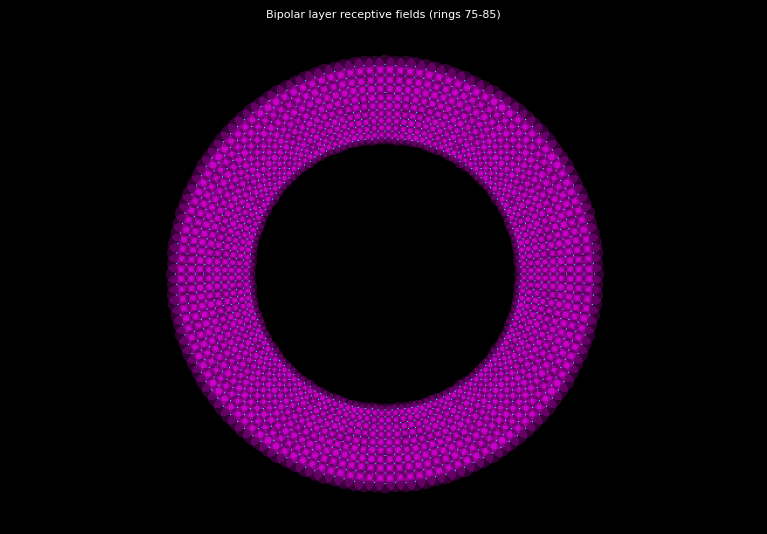

In [11]:
rbegin = 75
rend = 85

(fig, ax, _, _) = bl.plot_rfs(
    cells=bl.rfs.rings[rbegin:rend],
    title=f"Bipolar layer receptive fields (rings {rbegin}-{rend})",
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


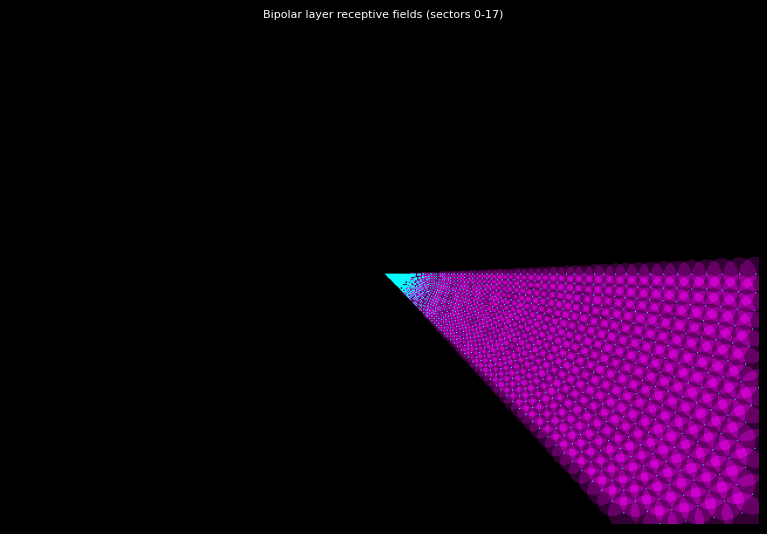

In [12]:
sbegin = 0
send = 17

(fig, ax, _, _) = bl.plot_rfs(
    cells=bl.rfs.sectors[sbegin:send],
    title=f"Bipolar layer receptive fields (sectors {sbegin}-{send})",
)

## Amacrine layer

In [13]:
al_params = {
    "size": size,
    "bipolar": bl,
    "sectors": 64,
    "rf_params": {
        "kernel_params": {
            "filter": pct.KernelFilter.Flat,
            "min_size": 3,
            "scale": 1.25,
        }
    },
}

al = AmacrineLayer(**al_params)

Pyrception | 2024-06-27@00:07:24 | Amacrine | Initialising...
Pyrception | 2024-06-27@00:07:24 | Amacrine | Amacrine RFs | Creating receptive fields...


Neurons created: 100%|██████████| 2595/2595 [00:00<00:00, 3792.32it/s]


Pyrception | 2024-06-27@00:07:25 | Amacrine | Amacrine RFs | Receptive fields created for 2595 neurons.
Pyrception | 2024-06-27@00:07:25 | Amacrine | Initialised.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


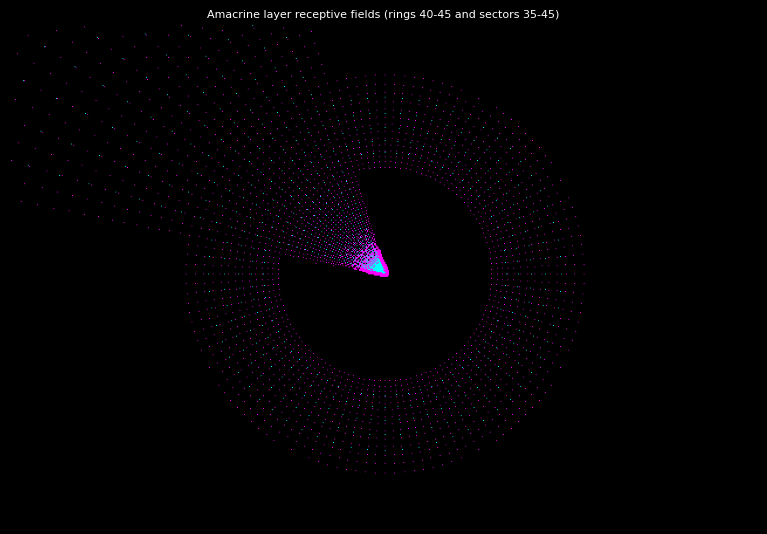

In [14]:
rbegin = 40
rend = 45

sbegin = 35
send = 45

(fig, ax, _, _) = al.plot_rfs(
    cells=[
        al.rfs.sectors[sbegin:send],
        al.rfs.rings[rbegin:rend],
    ],
    title=f"Amacrine layer receptive fields (rings {rbegin}-{rend} and sectors {sbegin}-{send})",
)

Receptive field for a single amacrine cell (highlights the sparsity of the input)

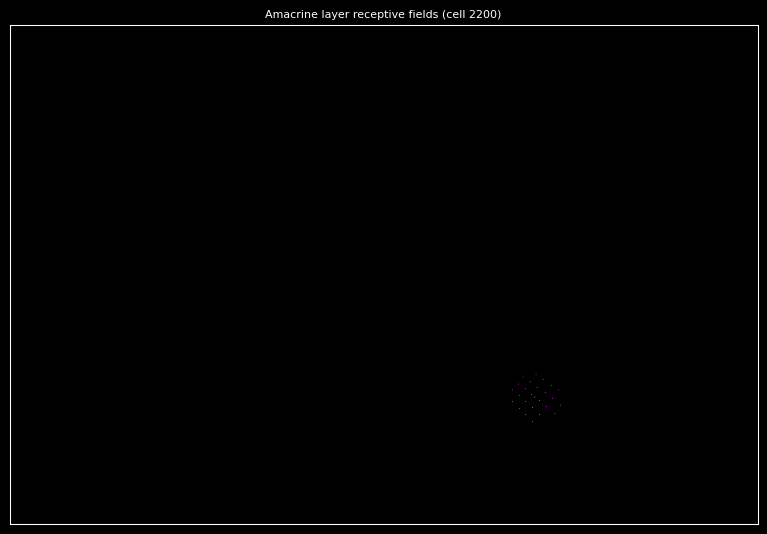

In [15]:
cell = 2200
(fig, ax, _, _) = al.plot_rfs(cells=cell, spines = True, title=f"Amacrine layer receptive fields (cell {cell})")

## Ganglion layer

In [16]:
gl_bl_params = {
    "kernel_params": {
        "scale": 1.0,
        "filter": pct.KernelFilter.Flat,
    }
}
gl_al_params = {
    "kernel_params": {
        "scale": 1.25,
        "filter": pct.KernelFilter.Flat,
    },
}


gl_params = {
    "size": size,
    "bipolar": bl,
    "amacrine": al,
    "sectors": 96,
    "bipolar_params": gl_bl_params,
    "amacrine_params": gl_al_params,
}

gl = GanglionLayer(**gl_params)

Pyrception | 2024-06-27@00:07:25 | Ganglion | Initialising...
Pyrception | 2024-06-27@00:07:25 | Ganglion | Bipolar RFs | Creating receptive fields...


Neurons created: 100%|██████████| 5131/5131 [00:01<00:00, 3504.83it/s]


Pyrception | 2024-06-27@00:07:27 | Ganglion | Bipolar RFs | Receptive fields created for 5131 neurons.
Pyrception | 2024-06-27@00:07:27 | Ganglion | Amacrine RFs | Creating receptive fields...


Neurons created: 100%|██████████| 5131/5131 [00:01<00:00, 3163.60it/s]


Pyrception | 2024-06-27@00:07:29 | Ganglion | Amacrine RFs | Receptive fields created for 5131 neurons.
Pyrception | 2024-06-27@00:07:29 | Ganglion | Initialised.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


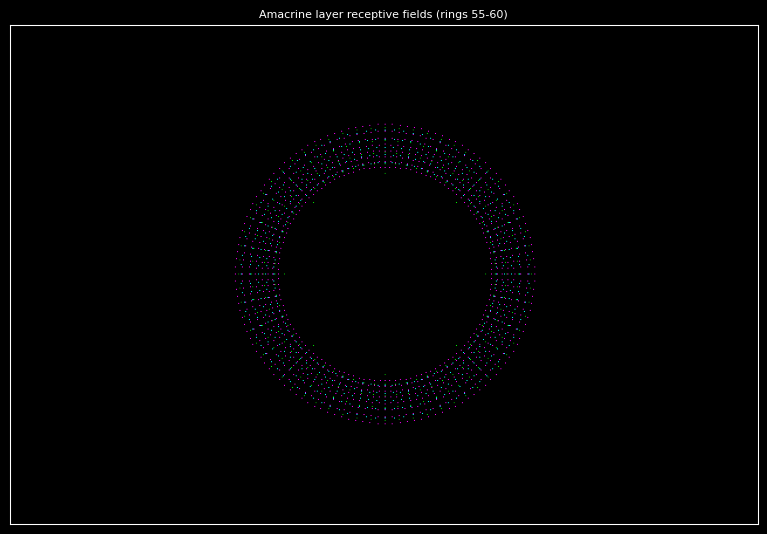

In [17]:
rbegin = 55
rend = 60

(fig, ax, _, _) = gl.plot_rfs(
    cells=gl.amacrine_rfs.rings[rbegin:rend],
    spines=True,
    title = f"Amacrine layer receptive fields (rings {rbegin}-{rend})"
)

Process the image with the horizontal layer and plot the activations as a scatter plot.

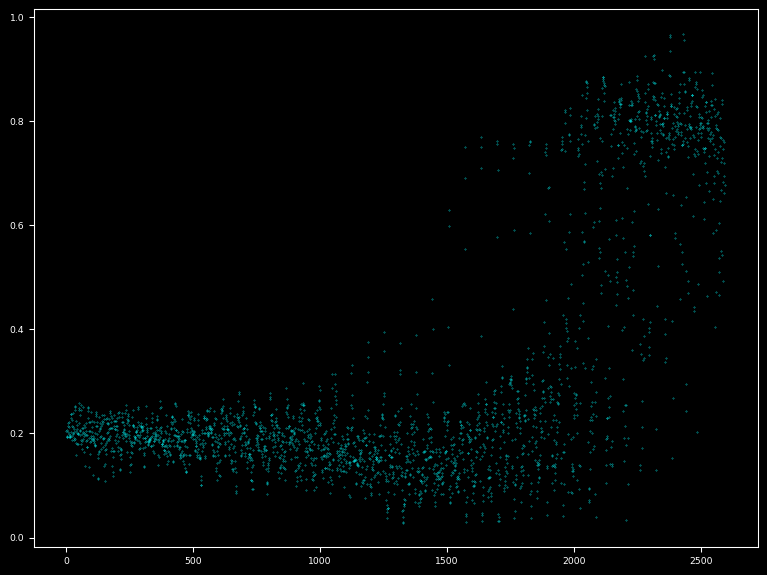

In [18]:
rl_activation = rl.forward(img)
(hl_activation, hl_feedback) = hl.forward()
hl_feedback = hl_feedback.reshape(hl.rfs.height, hl.rfs.width)
response_xs = pt.linspace(0, len(hl_activation), len(hl_activation))

hl_act_plot = scatplot(hl_activation, axis = True)

(fig, _, _) = pf.plot(
    hl_act_plot,
    figsize=(8, 6),
    **plot_kw,
)

Compute the normalised version of the raw input by subtracting the mean illumination map. The normalised input is then passed to the bipolar layer.

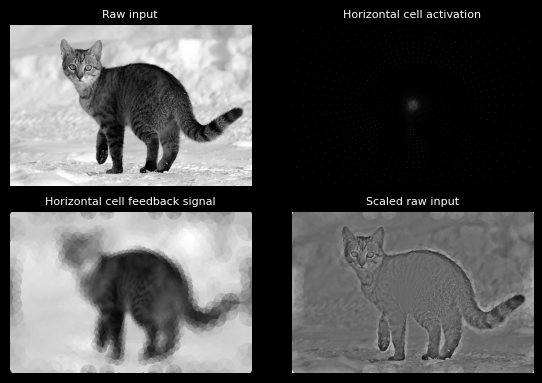

In [19]:
hl_act_canvas = np.zeros((h, w))

hl_act_canvas[
    hl.rfs.cell_coordinates[:, 0],
    hl.rfs.cell_coordinates[:, 1],
] = hl_activation

raw_plot = implot(img, title = "Raw input")
hl_act_plot = implot(hl_act_canvas, title = "Horizontal cell activation")
fbs_plot = implot(hl_feedback, title = "Horizontal cell feedback signal")
scaled_plot = implot(img - hl_feedback, title = "Scaled raw input")

(fig, _, _) = pf.plot(
    [
        [raw_plot, hl_act_plot],
        [fbs_plot, scaled_plot],
    ],
    **plot_kw,
)

In [20]:
(bl_on, bl_off, _, _) = bl.forward()

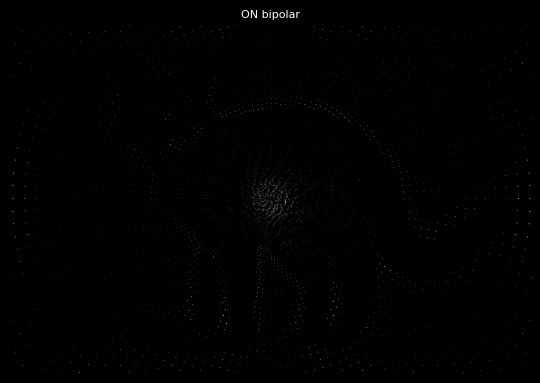

In [21]:
bp_on_canvas = np.zeros((h, w))
bp_off_canvas = np.zeros((h, w))

bp_on_canvas[bl.rfs.cell_coordinates[:, 0], bl.rfs.cell_coordinates[:, 1]] = bl_on
bp_off_canvas[bl.rfs.cell_coordinates[:, 0], bl.rfs.cell_coordinates[:, 1]] = bl_off

on_plot = implot(bp_on_canvas, title = "ON bipolar")
off_plot = implot(bp_off_canvas, title = "OFF bipolar")

(fig, _, _) = pf.plot(
    [on_plot],
    **plot_kw,
)

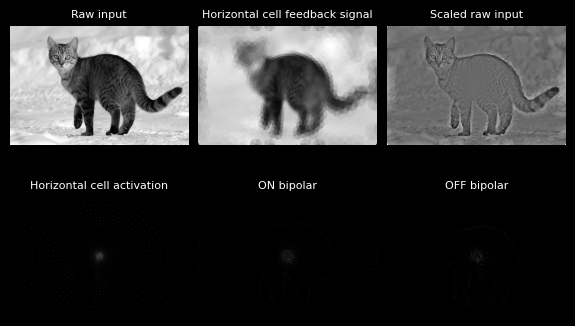

In [22]:
(fig, _, _) = pf.plot(
    [
        [raw_plot, fbs_plot, scaled_plot],
        [hl_act_plot, on_plot, off_plot],
    ],
    **plot_kw,
)

In [23]:
(al_on, al_off) = al.forward()

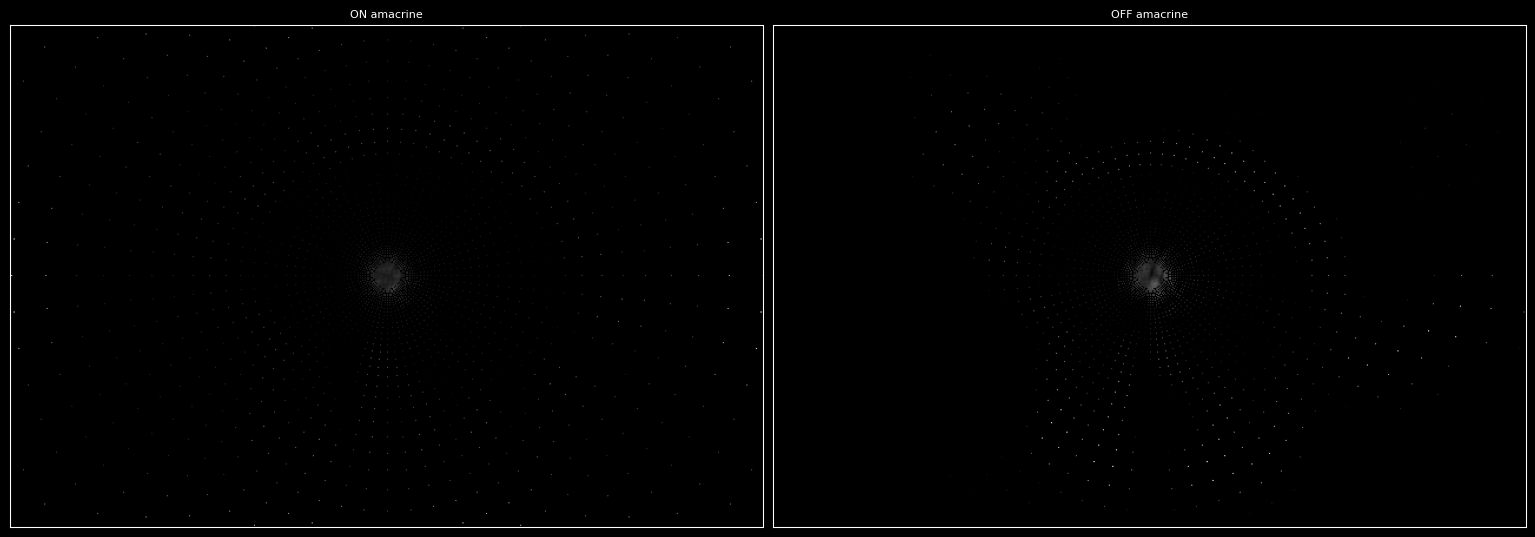

In [24]:
al_on_canvas = np.zeros((h, w))
al_off_canvas = np.zeros((h, w))

al_on_canvas[al.rfs.cell_coordinates[:, 0], al.rfs.cell_coordinates[:, 1]] = al_on
al_off_canvas[al.rfs.cell_coordinates[:, 0], al.rfs.cell_coordinates[:, 1]] = al_off

al_on_plot = implot(al_on_canvas, title="ON amacrine", spines=True)
al_off_plot = implot(al_off_canvas, title="OFF amacrine", spines=True)

(fig, _, _) = pf.plot(
    [al_on_plot, al_off_plot],
    # [al_on_plot],
    # [al_off_plot],
    figsize=(16, 10),
    **plot_kw,
)

In [25]:
(gl_on_off, gl_off_on) = gl.forward()

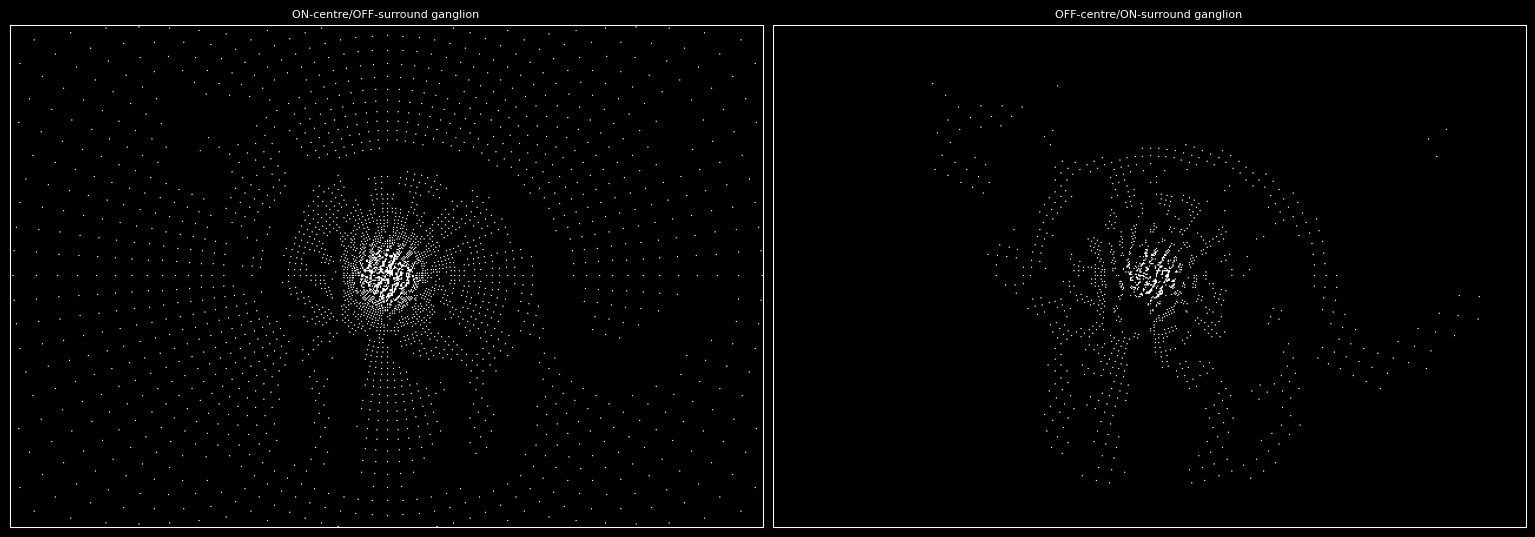

In [26]:
gl_on_off_canvas = np.zeros((h, w))
gl_off_on_canvas = np.zeros((h, w))

gl_on_off_canvas[
    gl.amacrine_rfs.cell_coordinates[:, 0], gl.amacrine_rfs.cell_coordinates[:, 1]
] = gl_on_off
gl_off_on_canvas[
    gl.amacrine_rfs.cell_coordinates[:, 0], gl.amacrine_rfs.cell_coordinates[:, 1]
] = gl_off_on

gl_on_off_plot = implot(
    gl_on_off_canvas, title="ON-centre/OFF-surround ganglion", spines=True
)
gl_off_on_plot = implot(
    gl_off_on_canvas, title="OFF-centre/ON-surround ganglion", spines=True
)

(fig, _, _) = pf.plot(
    [gl_on_off_plot, gl_off_on_plot],
    figsize=(16, 10),
    **plot_kw,
)

In [27]:
print(f"==[ Active ganglion cells:")
print(f"==[ ON/OFF: {gl_on_off.sum()} / {len(gl_on_off)}")
print(f"==[ OFF/ON: {gl_off_on.sum()} / {len(gl_off_on)}")
print(f"==[ Total: {gl_on_off.sum() + gl_off_on.sum()}")

==[ Active ganglion cells:
==[ ON/OFF: 3231 / 5131
==[ OFF/ON: 1268 / 5131
==[ Total: 4499
